In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("heart.csv")

In [3]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


#EDA

In [4]:
df.shape

(918, 12)

In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

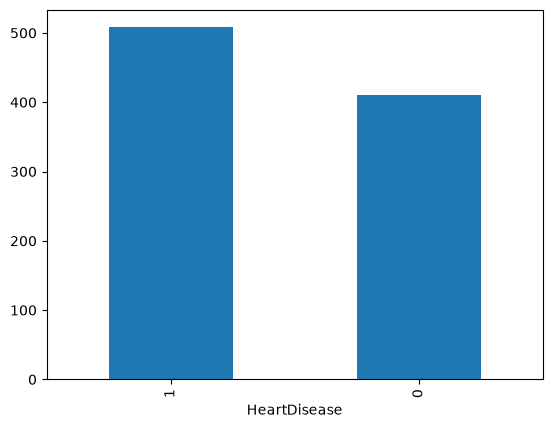

In [9]:
df["HeartDisease"].value_counts().plot(kind="bar")

In [10]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

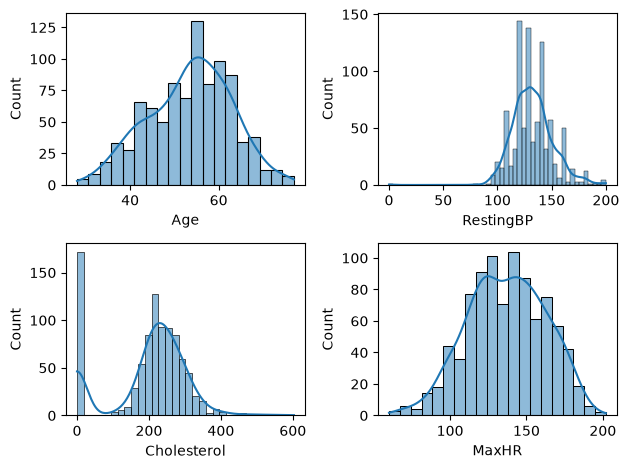

In [11]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting("Age",1)
plotting("RestingBP",2)
plotting("Cholesterol",3)
plotting("MaxHR",4)

plt.tight_layout()

In [12]:
df["Cholesterol"].value_counts()

Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [13]:
ch_mean=df.loc[df["Cholesterol"] != 0, "Cholesterol"].mean()

In [14]:
ch_mean

np.float64(244.6353887399464)

In [15]:
df["Cholesterol"]=df["Cholesterol"].replace(0,ch_mean)
df["Cholesterol"]=df["Cholesterol"].round(2)

In [16]:
df['Cholesterol'].value_counts()

Cholesterol
244.64    172
254.00     11
220.00     10
223.00     10
204.00      9
         ... 
353.00      1
278.00      1
157.00      1
176.00      1
131.00      1
Name: count, Length: 222, dtype: int64

In [17]:
re_mean=df.loc[df["RestingBP"] !=0,"RestingBP"].mean()

In [18]:
re_mean

np.float64(132.54089422028352)

In [19]:
df["RestingBP"]=df["RestingBP"].replace(0,re_mean)
df["RestingBP"]=df["RestingBP"].round(2)

In [20]:
df["RestingBP"].value_counts()

RestingBP
120.0    132
130.0    118
140.0    107
110.0     58
150.0     55
        ... 
101.0      1
117.0      1
192.0      1
129.0      1
164.0      1
Name: count, Length: 67, dtype: int64

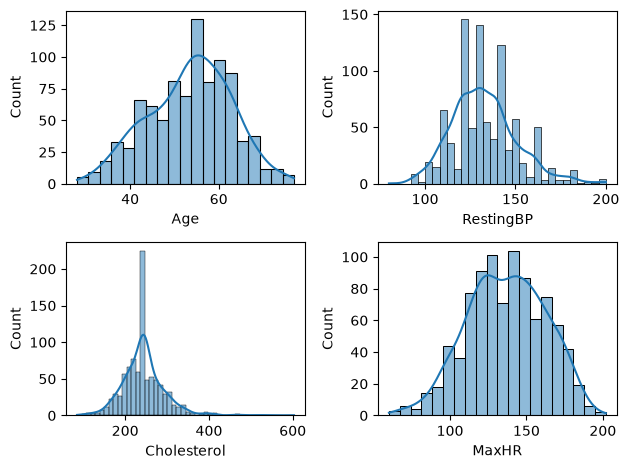

In [21]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting("Age",1)
plotting("RestingBP",2)
plotting("Cholesterol",3)
plotting("MaxHR",4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

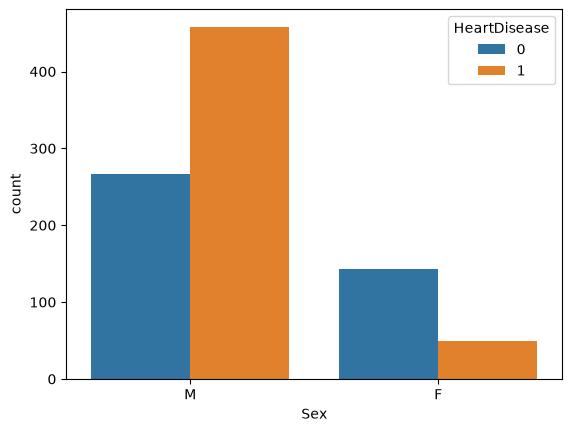

In [22]:
sns.countplot(x=df["Sex"],hue=df["HeartDisease"])

<Axes: xlabel='ChestPainType', ylabel='count'>

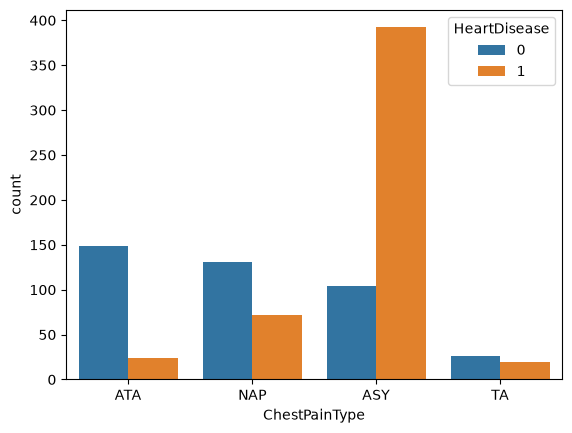

In [23]:
sns.countplot(x=df["ChestPainType"],hue=df["HeartDisease"])

<Axes: xlabel='FastingBS', ylabel='count'>

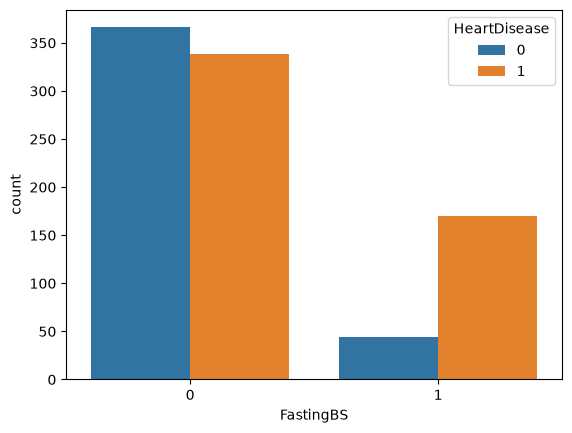

In [24]:
sns.countplot(x=df["FastingBS"],hue=df["HeartDisease"])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

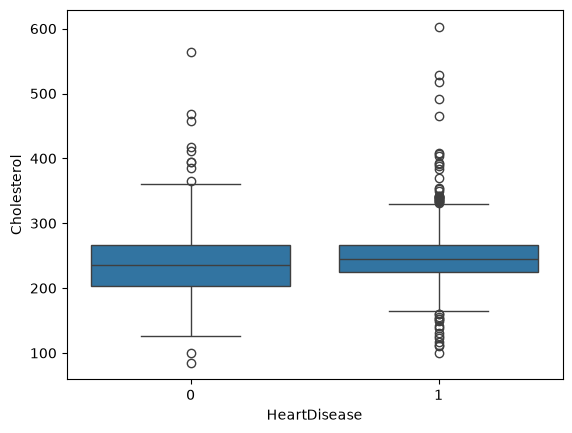

In [25]:
sns.boxplot(x="HeartDisease", y="Cholesterol", data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

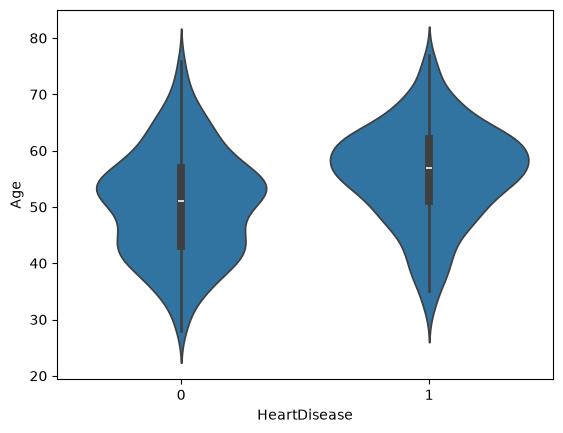

In [26]:
sns.violinplot(x="HeartDisease",y="Age", data=df)

<Axes: >

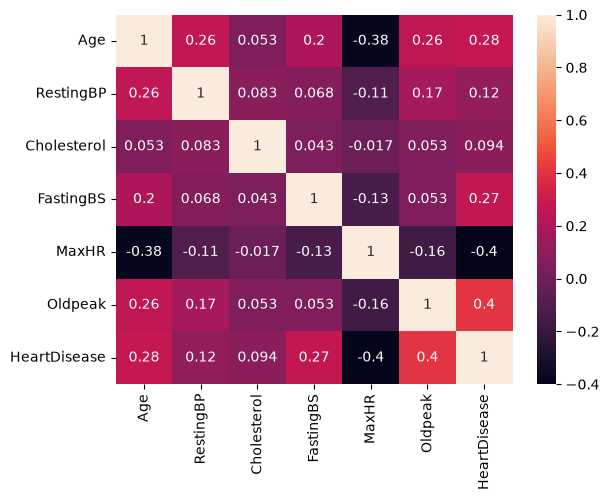

In [27]:
sns.heatmap(df.corr(numeric_only = True), annot=True)

#Data preprocessing and cleaning

In [28]:
df_encode = pd.get_dummies(df,drop_first=True)

In [29]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [30]:
df_encode=df_encode.astype(int)

In [31]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [32]:
from sklearn.preprocessing import StandardScaler
numerical_col=["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]
scaler=StandardScaler()
df_encode[numerical_col]=scaler.fit_transform(df_encode[numerical_col])

In [33]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253622,0.365619,0,-0.188999,0.282891,1,1,0,0,1,1,0,0,1,0
914,1.536902,0.637353,-0.966725,1,0.164684,2.303858,1,1,0,0,0,1,0,0,1,0
915,0.370100,-0.141284,-2.130180,0,-0.857069,0.282891,1,1,0,0,0,1,0,1,1,0
916,0.370100,-0.141284,-0.159813,0,1.461525,-0.727592,1,0,1,0,0,0,0,0,1,0


In [34]:
numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak"
]

In [35]:
from scipy.stats import pearsonr

correlation_results = {}

for feature in numerical_features:
    correlation, p_value = pearsonr(
        df_encode[feature],
        df_encode["HeartDisease"]
    )
    
    correlation_results[feature] = {
        "correlation": correlation,
        "p_value": p_value
    }

correlation_df = pd.DataFrame(correlation_results).T

correlation_df = correlation_df.sort_values(
    by="correlation",
    ascending=False
)

correlation_df

,correlation,p_value
Oldpeak,0.392385,3.699537e-35
Age,0.282039,3.007953e-18
FastingBS,0.267291,1.753598e-16
RestingBP,0.117909,3.434863e-04
Cholesterol,0.092586,4.993963e-03
MaxHR,-0.400421,1.137786e-36


In [36]:
categorical_features = [
    col for col in df_encode.columns
    if col != "HeartDisease"
    and df_encode[col].nunique() <= 2
]
    
categorical_features

['FastingBS',
 'Sex_M',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_Y',
 'ST_Slope_Flat',
 'ST_Slope_Up']

In [37]:
from scipy.stats import chi2_contingency

chi2_results = {}

for feature in categorical_features:

    contingency_table = pd.crosstab(
        df_encode[feature],
        df_encode["HeartDisease"]
    )

    chi2_stat, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    chi2_results[feature] = {
        "chi2_stat": chi2_stat,
        "p_value": p_value
    }

chi2_df = pd.DataFrame(chi2_results).T

chi2_df = chi2_df.sort_values(
    by="p_value"
)

chi2_df

,chi2_stat,p_value
ST_Slope_Up,352.823905,1.028493e-78
ST_Slope_Flat,279.659914,8.906496e-63
ExerciseAngina_Y,222.259383,2.907808e-50
ChestPainType_ATA,146.236323,1.152597e-33
Sex_M,84.145101,4.597617e-20
FastingBS,64.320679,1.057302e-15
ChestPainType_NAP,40.608711,1.859758e-10
RestingECG_ST,9.135266,2.507290e-03
RestingECG_Normal,7.327532,6.790624e-03
ChestPainType_TA,2.273802,1.315768e-01


In [38]:
final_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "Sex_M",
    "ChestPainType_ATA",
    "ChestPainType_NAP",
    "RestingECG_Normal",
    "RestingECG_ST",
    "ExerciseAngina_Y",
    "ST_Slope_Flat",
    "ST_Slope_Up",
    "HeartDisease"
]

final_df = df_encode[final_features]

final_df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,HeartDisease
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,1,1,0,1,0,0,0,1,0
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,0,0,1,1,0,0,1,0,1
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,1,1,0,0,1,0,0,1,0
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,0,0,0,1,0,1,1,0,1
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,1,0,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253622,0.365619,0,-0.188999,0.282891,1,0,0,1,0,0,1,0,1
914,1.536902,0.637353,-0.966725,1,0.164684,2.303858,1,0,0,1,0,0,1,0,1
915,0.370100,-0.141284,-2.130180,0,-0.857069,0.282891,1,0,0,1,0,1,1,0,1
916,0.370100,-0.141284,-0.159813,0,1.461525,-0.727592,0,1,0,0,0,0,1,0,1


In [39]:
final_df.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'RestingECG_Normal',
       'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up',
       'HeartDisease'],
      dtype='object')

In [41]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [67]:
X=df_encode.drop("HeartDisease",axis=1)
y=df_encode["HeartDisease"]

In [68]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.20,
                                                  random_state=42)
                                            

In [69]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [70]:
models={
    "logistic Regression" : LogisticRegression(),
    "KNN" : KNeighborsClassifier(),
    "Naive Byeas" : GaussianNB(),
    "Decision tree" : DecisionTreeClassifier(),
    "SVC" : SVC()
}

In [71]:
results=[]

In [72]:
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_test_scaled)
    acc=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results.append({
        "model":name,
        "Accuracy":round(acc,4),
        "F1 Score":round(f1,4)
    })
        
    

In [73]:
results

[{'model': 'logistic Regression', 'Accuracy': 0.8696, 'F1 Score': 0.8857},
 {'model': 'KNN', 'Accuracy': 0.8641, 'F1 Score': 0.8815},
 {'model': 'Naive Byeas', 'Accuracy': 0.8533, 'F1 Score': 0.8683},
 {'model': 'Decision tree', 'Accuracy': 0.788, 'F1 Score': 0.8098},
 {'model': 'SVC', 'Accuracy': 0.8478, 'F1 Score': 0.8679}]

In [74]:
import joblib
joblib.dump(models["KNN"],"KNN-heart.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(X.columns.tolist(),"columns.pkl")


['columns.pkl']